# Week 2: Hidden Anomalies in Observed Data

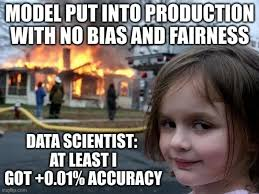

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("/data")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [ ]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df, label=None):
    raise NotImplementedError

# TODO: compare train, validation, and test feature distributions.
# Include categorical as well as numeric variables.

Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

# TODO: choose features and justify exclusions.
FEATURE_COLUMNS = []

# TODO: write a model factory that handles numeric and categorical columns.
def make_model(frame):
    raise NotImplementedError

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.

Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate, count
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# TODO: implement robust metric functions.
# TODO: construct MetricFrame for SEX_group and at least one intersection.

### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

In [ ]:
# TODO: implement calibration tables, reliability plots, and a numerical summary such as ECE.
# State how you handle small bins and why your binning choice is defensible.

# TODO: Mitigation

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

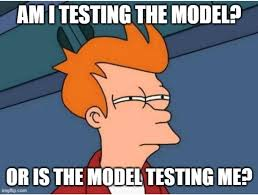

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
